## Breast Cancer Classification 

Using scikit-learn, do classification of breast cancer based on biopsy features.
```python
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
# 0->malignant and 1->benign
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='cancer_type')
```

Split the data into training and testing, and train different classifiers to classify into either benign or malignant. Compute test metrics on the test dataset (accuracy, confusion matrix, recall and precision, etc.). Compare different classifiers of your choice -- including for example, logistic regression, bag of decision trees, random forest and kNN.

### Load Data

In [6]:
# Load breast cancer data from sklearn
from sklearn.datasets import load_breast_cancer

# Load the dataset
data = load_breast_cancer()

# Display dataset schema (features, shape, and target explanation)
print("Feature names:", data.feature_names)
print("Number of features:", len(data.feature_names))
print("Shape of data:", data.data.shape)
print("Target names:", data.target_names)



Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Number of features: 30
Shape of data: (569, 30)
Target names: ['malignant' 'benign']


### Display Data

In [12]:
import pandas as pd

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='cancer_type')

# Summary statistics for every feature
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [13]:
# First 20 samples with target label
df = X.copy()
df.insert(0, 'cancer_type', y.map({0: 'malignant', 1: 'benign'}))
df.head(20).style.set_caption("First 20 Samples")

,cancer_type,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,malignant,17.990000,10.380000,122.800000,1001.000000,0.118400,0.277600,0.300100,0.147100,0.241900,0.078710,1.095000,0.905300,8.589000,153.400000,0.006399,0.049040,0.053730,0.015870,0.030030,0.006193,25.380000,17.330000,184.600000,2019.000000,0.162200,0.665600,0.711900,0.265400,0.460100,0.118900
1,malignant,20.570000,17.770000,132.900000,1326.000000,0.084740,0.078640,0.086900,0.070170,0.181200,0.056670,0.543500,0.733900,3.398000,74.080000,0.005225,0.013080,0.018600,0.013400,0.013890,0.003532,24.990000,23.410000,158.800000,1956.000000,0.123800,0.186600,0.241600,0.186000,0.275000,0.089020
2,malignant,19.690000,21.250000,130.000000,1203.000000,0.109600,0.159900,0.197400,0.127900,0.206900,0.059990,0.745600,0.786900,4.585000,94.030000,0.006150,0.040060,0.038320,0.020580,0.022500,0.004571,23.570000,25.530000,152.500000,1709.000000,0.144400,0.424500,0.450400,0.243000,0.361300,0.087580
3,malignant,11.420000,20.380000,77.580000,386.100000,0.142500,0.283900,0.241400,0.105200,0.259700,0.097440,0.495600,1.156000,3.445000,27.230000,0.009110,0.074580,0.056610,0.018670,0.059630,0.009208,14.910000,26.500000,98.870000,567.700000,0.209800,0.866300,0.686900,0.257500,0.663800,0.173000
4,malignant,20.290000,14.340000,135.100000,1297.000000,0.100300,0.132800,0.198000,0.104300,0.180900,0.058830,0.757200,0.781300,5.438000,94.440000,0.011490,0.024610,0.056880,0.018850,0.017560,0.005115,22.540000,16.670000,152.200000,1575.000000,0.137400,0.205000,0.400000,0.162500,0.236400,0.076780
5,malignant,12.450000,15.700000,82.570000,477.100000,0.127800,0.170000,0.157800,0.080890,0.208700,0.076130,0.334500,0.890200,2.217000,27.190000,0.007510,0.033450,0.036720,0.011370,0.021650,0.005082,15.470000,23.750000,103.400000,741.600000,0.179100,0.524900,0.535500,0.174100,0.398500,0.124400
6,malignant,18.250000,19.980000,119.600000,1040.000000,0.094630,0.109000,0.112700,0.074000,0.179400,0.057420,0.446700,0.773200,3.180000,53.910000,0.004314,0.013820,0.022540,0.010390,0.013690,0.002179,22.880000,27.660000,153.200000,1606.000000,0.144200,0.257600,0.378400,0.193200,0.306300,0.083680
7,malignant,13.710000,20.830000,90.200000,577.900000,0.118900,0.164500,0.093660,0.059850,0.219600,0.074510,0.583500,1.377000,3.856000,50.960000,0.008805,0.030290,0.024880,0.014480,0.014860,0.005412,17.060000,28.140000,110.600000,897.000000,0.165400,0.368200,0.267800,0.155600,0.319600,0.115100
8,malignant,13.000000,21.820000,87.500000,519.800000,0.127300,0.193200,0.185900,0.093530,0.235000,0.073890,0.306300,1.002000,2.406000,24.320000,0.005731,0.035020,0.035530,0.012260,0.021430,0.003749,15.490000,30.730000,106.200000,739.300000,0.170300,0.540100,0.539000,0.206000,0.437800,0.107200
9,malignant,12.460000,24.040000,83.970000,475.900000,0.118600,0.239600,0.227300,0.085430,0.203000,0.082430,0.297600,1.599000,2.039000,23.940000,0.007149,0.072170,0.077430,0.014320,0.017890,0.010080,15.090000,40.680000,97.650000,711.400000,0.185300,1.058000,1.105000,0.221000,0.436600,0.207500


### Pre-processing

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Verify: each feature should have mean ~0 and std ~1
X_scaled.describe().T[['mean', 'std']]

,mean,std
mean radius,-1.373633e-16,1.00088
mean texture,6.868164e-17,1.00088
mean perimeter,-1.248757e-16,1.00088
mean area,-2.185325e-16,1.00088
mean smoothness,-8.366672e-16,1.00088
mean compactness,1.873136e-16,1.00088
mean concavity,4.995028e-17,1.00088
mean concave points,-4.995028e-17,1.00088
mean symmetry,1.748260e-16,1.00088
mean fractal dimension,4.745277e-16,1.00088


### Train / Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.1, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Train class distribution:\n{y_train.value_counts().rename({0: 'malignant', 1: 'benign'})}")
print("-------")
print(f"Test class distribution:\n{y_test.value_counts().rename({0: 'malignant', 1: 'benign'})}")

Training set: 512 samples
Test set:     57 samples
Train class distribution:
cancer_type
benign       321
malignant    191
Name: count, dtype: int64
-------
Test class distribution:
cancer_type
benign       36
malignant    21
Name: count, dtype: int64


### Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print(f"Coefficients shape: {lr_model.coef_.shape}")
print(f"Intercept: {lr_model.intercept_[0]:.4f}")

y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

# print("Predicted class labels (y_pred):")
# print(y_pred)
# print("\nPredicted probabilities for class 'benign' (y_prob):")
# print(y_prob)



Coefficients shape: (1, 30)
Intercept: 0.1652


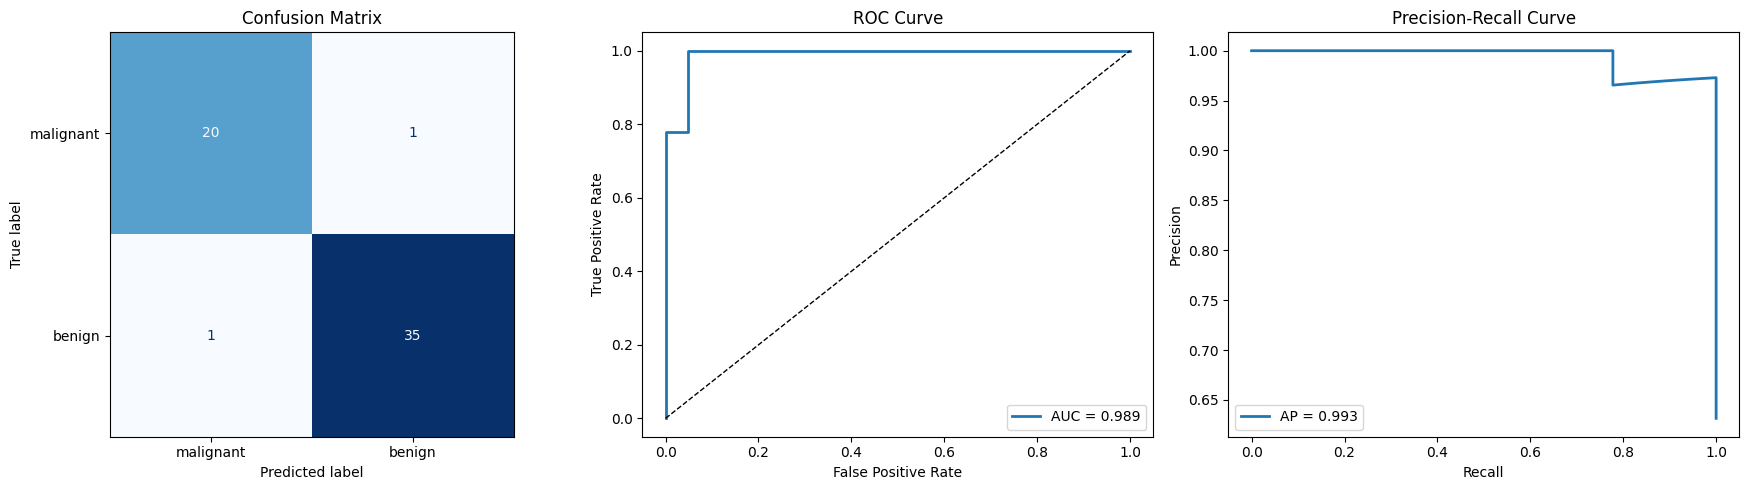

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['malignant', 'benign'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# 2) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

# 3) Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[2].plot(recall, precision, linewidth=2, label=f'AP = {ap:.3f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc='lower left')

fig.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import classification_report, accuracy_score

print("=== Classification Report ===\n")
print(classification_report(
    y_test, y_pred, target_names=['malignant', 'benign']
))
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {auc_score:.4f}")

=== Classification Report ===

              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        21
      benign       0.97      0.97      0.97        36

    accuracy                           0.96        57
   macro avg       0.96      0.96      0.96        57
weighted avg       0.96      0.96      0.96        57

Accuracy:  0.9649
ROC-AUC:   0.9894
